In [1]:
import pandas as pd

PATH = "00_data/"

payments = pd.read_csv(f"{PATH}olist_order_payments_dataset.csv", encoding="utf-8-sig")
orders = pd.read_csv(f"{PATH}olist_orders_dataset.csv", encoding="utf-8-sig")
products = pd.read_csv(f"{PATH}olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}olist_order_items_dataset.csv", encoding="utf-8-sig")
reviews = pd.read_csv(f"{PATH}olist_order_reviews_dataset.csv", encoding="utf-8-sig")
sellers = pd.read_csv(f"{PATH}olist_sellers_dataset.csv", encoding="utf-8-sig")
category_name = pd.read_csv(f"{PATH}product_category_name_translation.csv", encoding="utf-8-sig")

In [2]:
# 기간에 따른 판매 트랜드 확인!!!

In [4]:
# 구매건수 : orders
# 매출집계 : payments

In [8]:
orders.info()
# orders = orders.dropna()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [9]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [10]:
import pandas as pd

merged_order = pd.merge(orders, payments, on="order_id")

In [12]:
merged_order_payment_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()

In [14]:
merged_order_payment_date["order_purchase_timestamp"] = pd.to_datetime(merged_order_payment_date["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [16]:
# merged_order_payment_date.info()
merged_order_payment_date = merged_order_payment_date.set_index("order_purchase_timestamp")

In [19]:
# 25_260416 : 인덱스키가 되기 전, 일반 열을 기준으로 그룹퍼를 생성
# 26_260416 : 이미 인덱스키가 된 요소를 기준으로 그룹퍼를 생성 (굳이 key 매개변수 불필요)
merged_order_month_count = merged_order_payment_date.groupby(pd.Grouper(freq="ME")).count()

In [20]:
merged_order_month_count

,payment_value
order_purchase_timestamp,
2016-10-31,287
2016-11-30,0
2016-12-31,1
2017-01-31,797
2017-02-28,1737
2017-03-31,2700
2017-04-30,2436
2017-05-31,3786
2017-06-30,3323


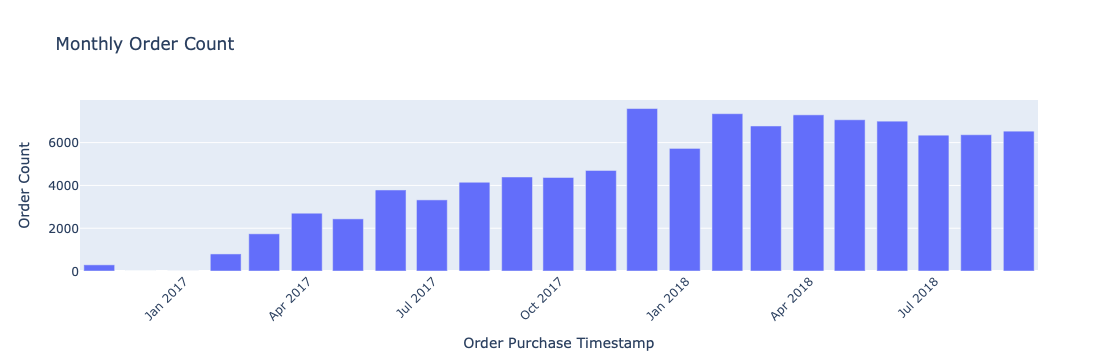

In [24]:
import plotly.express as px

fig = px.bar(
    x = merged_order_month_count.index,
    y = merged_order_month_count["payment_value"],
    title = "Monthly Order Count",
    labels = {
        "x": "Order Purchase Timestamp",
        "y": "Order Count",
    }
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [25]:
# 월간 판매 매출 비율 : 월간 판매 거래횟수 거의 비례한다 -> 인사이트

In [26]:
# 일간 매출 내역 :
merged_order_date_sum = merged_order_payment_date.groupby(pd.Grouper(freq="D")).sum()

In [27]:
merged_order_date_sum.head()

,payment_value
order_purchase_timestamp,
2016-10-03,595.14
2016-10-04,9821.42
2016-10-05,7209.50
2016-10-06,6733.52
2016-10-07,7096.69


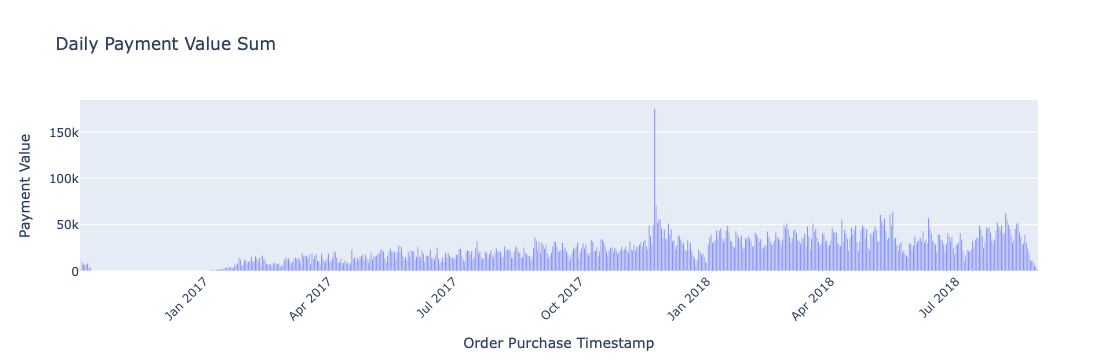

In [31]:
# 일간 매출 내역 시각화 :

import plotly.express as px

fig = px.bar(
    x = merged_order_date_sum.index,
    y = merged_order_date_sum["payment_value"],
    title = "Daily Payment Value Sum",
    labels = {
        "x": "Order Purchase Timestamp",
        "y": "Payment Value",
    }
)

fig.update_layout(xaxis_tickangle = -45)

fig.show()

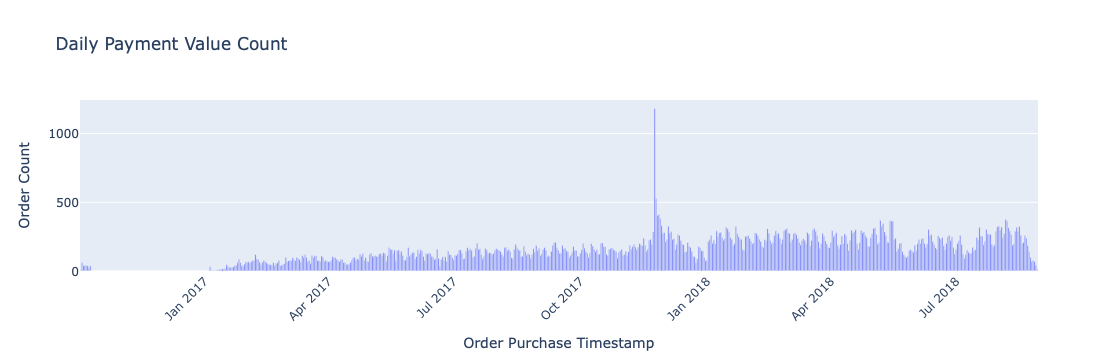

In [34]:
# 일간 매출 내역 시각화 :

import plotly.express as px

fig = px.bar(
    x = merged_order_date_count.index,
    y = merged_order_date_count["payment_value"],
    title = "Daily Payment Value Count",
    labels = {
        "x": "Order Purchase Timestamp",
        "y": "Order Count",
    }
)

fig.update_layout(xaxis_tickangle = -45)

fig.show()

In [32]:
merged_order_date_count = merged_order_payment_date.groupby(pd.Grouper(freq="D")).count()

In [33]:
merged_order_date_count

,payment_value
order_purchase_timestamp,
2016-10-03,8
2016-10-04,61
2016-10-05,38
2016-10-06,41
2016-10-07,40
...,...
2018-08-25,71
2018-08-26,76
2018-08-27,68


In [35]:
# 시간대별 분석

merged_order_payment_date = merged_order[["order_purchase_timestamp", "payment_value"]].copy()
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,18.12
1,2017-10-02 10:56:33,2.00
2,2017-10-02 10:56:33,18.59
3,2018-07-24 20:41:37,141.46
4,2018-08-08 08:38:49,179.12


In [38]:
merged_order_payment_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100739 entries, 0 to 100738
Data columns (total 2 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_purchase_timestamp  100739 non-null  datetime64[ns]
 1   payment_value             100739 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.5 MB


In [37]:
merged_order_payment_date["order_purchase_timestamp"] = pd.to_datetime(merged_order_payment_date["order_purchase_timestamp"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [ ]:
# 파이썬 안에 있는 각 변수의 타입 & 해당 타입에서 사용가능한 속성 및 메서드 등을 확인하고자 할 때, dir()

In [42]:
dir(merged_order_payment_date["order_purchase_timestamp"].dt)
# __, _ : 속성 => 객체.속성
# 일반문자열 : 메서드 => 객체.메서드()

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__frozen',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accessors',
 '_add_delegate_accessors',
 '_constructor',
 '_delegate_method',
 '_delegate_property_get',
 '_delegate_property_set',
 '_dir_additions',
 '_dir_deletions',
 '_freeze',
 '_get_values',
 '_hidden_attrs',
 '_parent',
 '_reset_cache',
 'as_unit',
 'ceil',
 'date',
 'day',
 'day_name',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'dayofyear',
 'days_in_month',
 'daysinmonth',
 'floor',
 'freq',
 'hour',
 'is_leap_year',
 'is_month_end',
 'is_month_start',
 'is_quarter_end',
 'is_quarter_start',
 'is_year_end',
 'is

In [43]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:33,18.12
1,2017-10-02 10:56:33,2.00
2,2017-10-02 10:56:33,18.59
3,2018-07-24 20:41:37,141.46
4,2018-08-08 08:38:49,179.12


In [45]:
# 1/4, 2/4, 3/4, 4/4 = 3개월 분기 나눌 수 있음
# 파이썬에서는 각 요소들이 사용할 수 있는 속성 혹은 메서드를 조회 : dir()
# order_purchase_timestamp : dir() => dt (datetime) : 해당 날짜 요소의 속성값을 조회 -> 어떤 데이터만 추출
# dt > year, month, quarter

merged_order_payment_date["year"] = merged_order_payment_date["order_purchase_timestamp"].dt.year
merged_order_payment_date["month"] = merged_order_payment_date["order_purchase_timestamp"].dt.month
merged_order_payment_date["quarter"] = merged_order_payment_date["order_purchase_timestamp"].dt.quarter
merged_order_payment_date["monthday"] = merged_order_payment_date["order_purchase_timestamp"].dt.day
merged_order_payment_date["weekday"] = merged_order_payment_date["order_purchase_timestamp"].dt.weekday
merged_order_payment_date["hour"] = merged_order_payment_date["order_purchase_timestamp"].dt.hour
merged_order_payment_date["minute"] = merged_order_payment_date["order_purchase_timestamp"].dt.minute

In [46]:
merged_order_payment_date.head()

,order_purchase_timestamp,payment_value,year,month,quarter,monthday,weekday,hour,minute
0,2017-10-02 10:56:33,18.12,2017,10,4,2,0,10,56
1,2017-10-02 10:56:33,2.00,2017,10,4,2,0,10,56
2,2017-10-02 10:56:33,18.59,2017,10,4,2,0,10,56
3,2018-07-24 20:41:37,141.46,2018,7,3,24,1,20,41
4,2018-08-08 08:38:49,179.12,2018,8,3,8,2,8,38


In [ ]:
# weekday
# 0 : 월요일, 1 : 화, 2 : 수 : 일 : 6
# 일반적인 프로그래밍 언어 : 0 -> 일반적으로는 일요일 인식
# 데이터를 취급하는 언어, 프로그램 -> 0 -> 월요일 

In [47]:
merged_order_payment_year = merged_order_payment_date[["year", "payment_value"]].copy()

In [48]:
merged_order_payment_year

,year,payment_value
0,2017,18.12
1,2017,2.00
2,2017,18.59
3,2018,141.46
4,2018,179.12
...,...,...
100734,2017,85.08
100735,2018,195.00
100736,2017,271.01
100737,2018,441.16


In [49]:
merged_order_payment_year = merged_order_payment_year.groupby("year").sum()
merged_order_payment_year.head()

,payment_value
year,
2016,47290.82
2017,6920422.83
2018,8451969.20


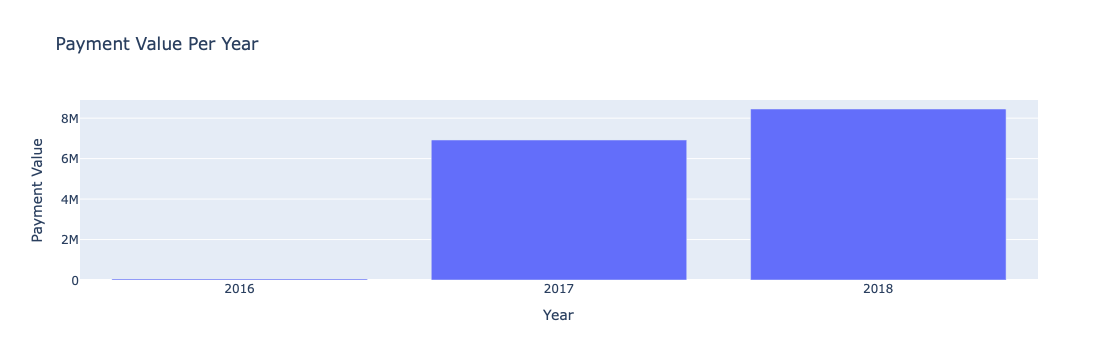

In [51]:
import plotly.express as px

fig = px.bar(
    x = merged_order_payment_year.index,
    y = merged_order_payment_year["payment_value"],
    title = "Payment Value Per Year",
    labels = {
        "x": "Year",
        "y": "Payment Value"
    }
)

fig.update_xaxes(
    tickvals=[2016, 2017, 2018]
)

fig.show()

In [52]:
merged_order_payment_weekday = merged_order_payment_date[["weekday", "payment_value"]].copy()

In [55]:
merged_order_payment_weekday = merged_order_payment_weekday.groupby("weekday").sum()
merged_order_payment_weekday

,payment_value
weekday,
0,2530671.56
1,2473930.77
2,2396215.34
3,2283849.51
4,2222421.36
5,1704949.69
6,1807644.62


In [56]:
merged_order_payment_weekday = merged_order_payment_weekday.reset_index()

In [58]:
merged_order_payment_weekday

,weekday,payment_value
0,0,2530671.56
1,1,2473930.77
2,2,2396215.34
3,3,2283849.51
4,4,2222421.36
5,5,1704949.69
6,6,1807644.62


In [ ]:
# apply() => 각 행마다 어떤 기능을 적용하고 싶은데, 그럼 행마다 반복적으로 적용할 수 있도록해주는 함수
# 0 -> 월요일 (0 값이 문자열)

In [59]:
merged_order_payment_weekday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weekday        7 non-null      int32  
 1   payment_value  7 non-null      float64
dtypes: float64(1), int32(1)
memory usage: 216.0 bytes


In [60]:
merged_order_payment_weekday["weekday"] = merged_order_payment_weekday["weekday"].astype(object)

In [61]:
merged_order_payment_weekday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weekday        7 non-null      object 
 1   payment_value  7 non-null      float64
dtypes: float64(1), object(1)
memory usage: 244.0+ bytes


In [62]:
merged_order_payment_weekday # "0"

,weekday,payment_value
0,0,2530671.56
1,1,2473930.77
2,2,2396215.34
3,3,2283849.51
4,4,2222421.36
5,5,1704949.69
6,6,1807644.62


In [64]:
def func(row) :
    if row["weekday"] == 0 :
        row["weekday"] = "Mon"
    elif row["weekday"] == 1 :
        row["weekday"] = "Tue"
    elif row["weekday"] == 2 :
        row["weekday"] = "Wed"
    elif row["weekday"] == 3 :
        row["weekday"] = "Thu"
    elif row["weekday"] == 4 :
        row["weekday"] = "Fri"
    elif row["weekday"] == 5 :
        row["weekday"] = "Sat"
    elif row["weekday"] == 6 :
        row["weekday"] = "Sun"

    return row

In [65]:
merged_order_payment_weekday = merged_order_payment_weekday.apply(func, axis=1)

In [66]:
merged_order_payment_weekday

,weekday,payment_value
0,Mon,2530671.56
1,Tue,2473930.77
2,Wed,2396215.34
3,Thu,2283849.51
4,Fri,2222421.36
5,Sat,1704949.69
6,Sun,1807644.62


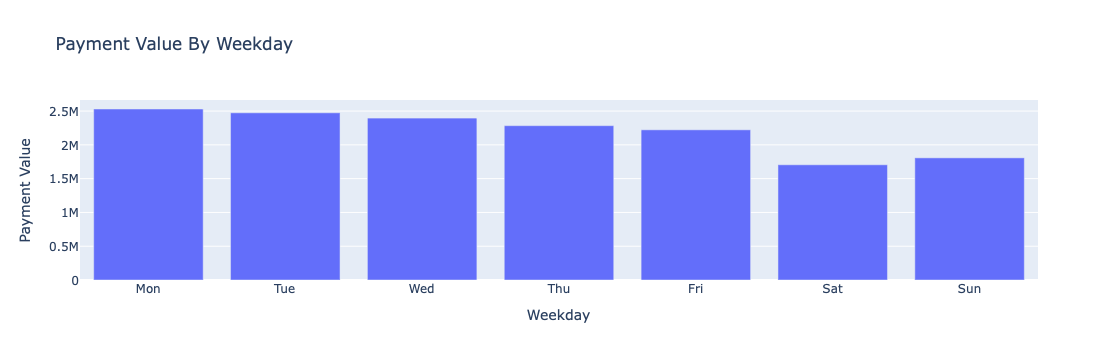

In [68]:
import plotly.express as px

fig = px.bar(
    x = merged_order_payment_weekday["weekday"],
    y = merged_order_payment_weekday["payment_value"],
    title = "Payment Value By Weekday",
    labels = {
        "x": "Weekday",
        "y": "Payment Value"
    }
)

fig.show()